# BIXI Station Map
Interactive map of all BIXI bike-share stations, plotted from `station_information.json`.

In [1]:
import json
import folium

DATA_PATH = "/Volumes/Extreme SSD/SUMO Data/station_information.json"

In [2]:
with open(DATA_PATH) as f:
    raw = json.load(f)

stations = [
    s for s in raw["data"]["stations"]
    if s["lat"] != 0 and s["lon"] != 0
]

print(f"{len(stations)} valid stations loaded")

1059 valid stations loaded


In [3]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]

bounds = [[min(lats), min(lons)], [max(lats), max(lons)]]

m = folium.Map(tiles="CartoDB positron")
m.fit_bounds(bounds, padding=(24, 24))

for s in stations:
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=4,
        color="#e63e2a",
        fill=True,
        fill_color="#e63e2a",
        fill_opacity=0.85,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>{s['name']}</b><br>ID: {s['station_id']}<br>Capacity: {s['capacity']}",
            sticky=False,
        ),
    ).add_to(m)

m

## Rive-Sud (South Shore) Stations
Stations within a set radius of central Longueuil, used as a proxy for the south shore cluster.

In [4]:
import math

LONGUEUIL_CENTER = (45.5219, -73.4645)
RADIUS_KM = 6  # adjust as needed

def haversine_km(lat1, lon1, lat2, lon2):
    # Returns distance in kilometers between two lat/lon points based on the earth's curvature
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

rive_sud = [
    s for s in stations
    if haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], s["lat"], s["lon"]) <= RADIUS_KM
]

print(f"Stations within {RADIUS_KM} km of Longueuil center: {len(rive_sud)}")
for s in sorted(rive_sud, key=lambda x: haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], x["lat"], x["lon"])):
    dist = haversine_km(LONGUEUIL_CENTER[0], LONGUEUIL_CENTER[1], s["lat"], s["lon"])
    print(f"  {dist:4.1f} km  [{s['station_id']:>4}] {s['name']}")

Stations within 6 km of Longueuil center: 81
   0.1 km  [1035] Faribault / de Chambly
   0.6 km  [1039] des Ormeaux / Mathieu
   0.6 km  [1053] Montarville / Beaubien
   0.8 km  [1040] Sacré-Coeur / Gamache
   0.9 km  [1036] Darveau / de Lyon
   1.0 km  [1160] Racicot / Roberval
   1.2 km  [1034] Roland-Therrien / Jacques-Cartier
   1.3 km  [1175] Parc Lecavalier (McGill)
   1.4 km  [1177] Parc Marquette (Nobert)
   1.5 km  [1046] Parc Gentilly Ouest (Belcourt / Bagot)
   1.5 km  [ 881] Parc Laurier (Laurier / Dubuc)
   1.5 km  [1041] Ste-Hélène / Papineau
   1.7 km  [ 879] Hôpital Pierre-Boucher (Jacques-Cartier / Bourdon)
   1.8 km  [1172] Roland-Therrien / Roberval /
   1.8 km  [1037] Roland-Therrien / Antoinette-Robidoux
   1.8 km  [1162] Curé-Poirier / Joliette
   1.9 km  [1159] Parc Belcourt (Bariteau)
   1.9 km  [1043] Cuvillier / de Chambly
   2.0 km  [1166] Curé-Poirier / Roland-Therrien
   2.1 km  [ 898] Beauregard / La Salle
   2.1 km  [ 880] Lamarre / Lavallée
   2.2 km  [ 

In [5]:
rive_sud_ids = {s["station_id"] for s in rive_sud}

m2 = folium.Map(tiles="CartoDB positron")

for s in stations:
    is_rs = s["station_id"] in rive_sud_ids
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=5 if is_rs else 3,
        color="#0057b8" if is_rs else "#aaaaaa",
        fill=True,
        fill_color="#0057b8" if is_rs else "#cccccc",
        fill_opacity=0.9 if is_rs else 0.5,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>{s['name']}</b><br>ID: {s['station_id']}<br>Capacity: {s['capacity']}"
            + (" <i>(Rive-Sud)</i>" if is_rs else ""),
            sticky=False,
        ),
    ).add_to(m2)

# Draw the radius circle
folium.Circle(
    location=LONGUEUIL_CENTER,
    radius=RADIUS_KM * 1000,
    color="#0057b8",
    fill=False,
    weight=1.5,
    dash_array="6",
    tooltip=f"Longueuil center, {RADIUS_KM} km radius",
).add_to(m2)

# Fit to Longueuil area
all_lats = [s["lat"] for s in stations]
all_lons = [s["lon"] for s in stations]
m2.fit_bounds([[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]], padding=(24, 24))
m2

In [6]:
import osmnx as ox

bounding_box = [-73.62368, 45.44845, -73.43142, 45.53822]
G = ox.graph.graph_from_bbox(bounding_box, network_type="bike")

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_50623/49112894.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


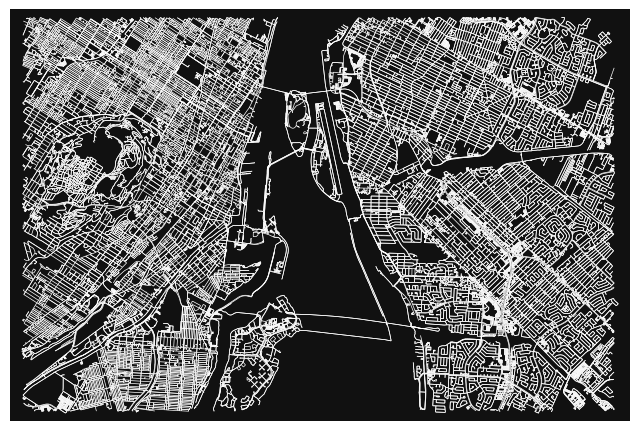

In [7]:
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
fig.show()

## Trip Heatmap on Longueuil Bike Network
Rides from the 2026 dataset whose start **or** end station is a Rive-Sud station (m2), routed as shortest paths on G and displayed as a heatmap. Shortest paths are computed once per unique OD node pair. (Shortest Path = Dijstra's algorithm)

In [11]:
import pandas as pd
from collections import defaultdict

CSV_2025 = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2025_010203040506070809101112.csv"
CSV_2026 = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2026_01020304.csv"

rive_sud_names = {s["name"] for s in rive_sud}

cols = ["STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE",
        "ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"]

def filter_csv(path, names_set, chunksize=200_000):
    """Read CSV in chunks, keep only rows touching a station in names_set."""
    chunks = []
    for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize):
        chunk = chunk.dropna()
        mask = chunk["STARTSTATIONNAME"].isin(names_set) | chunk["ENDSTATIONNAME"].isin(names_set)
        filtered = chunk[mask]
        if not filtered.empty:
            chunks.append(filtered)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=cols)

print("Loading 2025…")
trips_2025 = filter_csv(CSV_2025, rive_sud_names)
print(f"  {len(trips_2025):,} matching trips")

# print("Loading 2026…")
# trips_2026 = filter_csv(CSV_2026, rive_sud_names)
# print(f"  {len(trips_2026):,} matching trips")

# trips = pd.concat([trips_2025, trips_2026], ignore_index=True)
# print(f"Combined: {len(trips):,} trips")
trips = trips_2025

Loading 2025…


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_50623/895804400.py:15: DtypeWarning: Columns (0: ENDSTATIONLATITUDE) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize):


  117,945 matching trips


In [12]:
import networkx as nx

# --- Step 1: build station-name → (lat, lon) from the filtered trips ---
station_coords = {}
for col_name, col_lat, col_lon in [
    ("STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE"),
    ("ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"),
]:
    for _, row in trips[[col_name, col_lat, col_lon]].drop_duplicates(col_name).iterrows():
        station_coords[row[col_name]] = (row[col_lat], row[col_lon])

# --- Step 2: bulk nearest-node lookup (one call, all stations at once) ---
names  = list(station_coords)
lats   = [station_coords[n][0] for n in names]
lons   = [station_coords[n][1] for n in names]
nodes  = ox.distance.nearest_nodes(G, lons, lats)
station_to_node = dict(zip(names, nodes))

# --- Step 3: count trips per unique (src_node, dst_node) pair ---
pair_counts = defaultdict(int)
for _, row in trips.iterrows():
    src = station_to_node.get(row["STARTSTATIONNAME"])
    dst = station_to_node.get(row["ENDSTATIONNAME"])
    if src and dst and src != dst:
        pair_counts[(src, dst)] += 1

print(f"Unique OD node pairs: {len(pair_counts):,}")

# --- Step 4: shortest path per unique pair, accumulate edge weights ---
edge_load = defaultdict(int)
skipped = 0
for (src, dst), count in pair_counts.items():
    try:
        # Note: if this is too slow, we can consider A* by nx.astar_path with a heuristic based on straight-line distance
        # Or we can also proceed with ALT by precomputing landmarks and using nx.shortest_path with the "ALT" method and the precomputed landmark distances as heuristic
        path = nx.shortest_path(G, src, dst, weight="length")
        for u, v in zip(path[:-1], path[1:]):
            edge_load[(u, v)] += count
    except nx.NetworkXNoPath:
        skipped += 1

print(f"Edges with load: {len(edge_load):,}  |  Skipped (no path): {skipped}")

Unique OD node pairs: 11,215
Edges with load: 14,187  |  Skipped (no path): 157


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_50623/2306591238.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


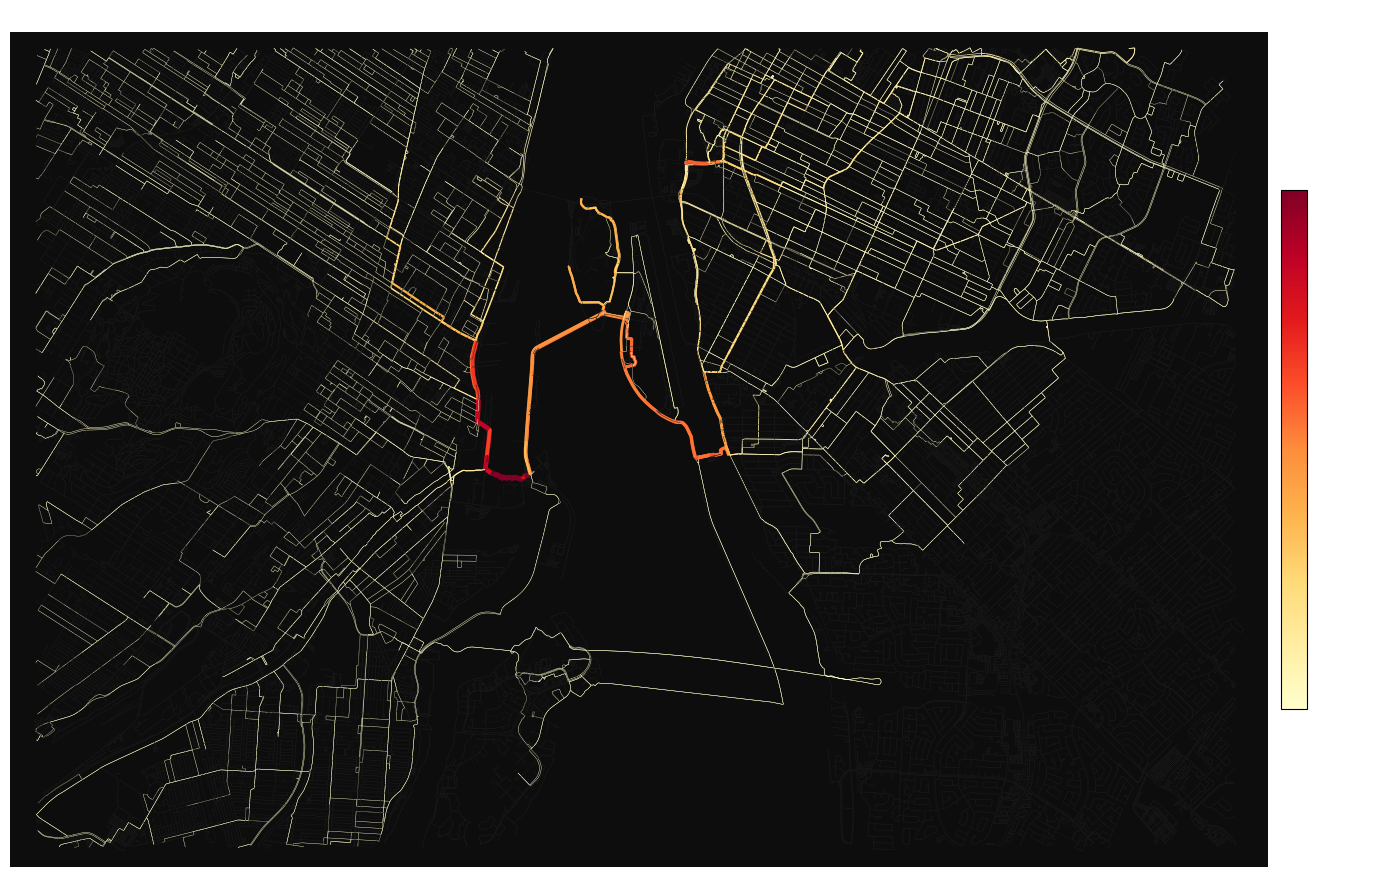

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

max_load = max(edge_load.values()) if edge_load else 1
cmap = plt.cm.YlOrRd
no_load_color = mcolors.to_rgba("#1a1a1a")  # RGBA tuple — same type as cmap()

edge_colors = []
edge_widths  = []
for u, v, _ in G.edges(keys=True):
    load = edge_load.get((u, v), 0)
    norm = load / max_load
    edge_colors.append(cmap(norm) if load > 0 else no_load_color)
    edge_widths.append(0.3 + 3.5 * norm)

fig, ax = ox.plot.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=0,
    bgcolor="#0d0d0d",
    show=False, close=False,
    figsize=(14, 10),
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, max_load))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Trip volume", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Rive-Sud Trip Heatmap (shortest path)", color="white", fontsize=13)
fig.tight_layout()
fig.show()